# BC Health Platform — Data Exploration
**Notebook 01**: Exploring the Kaggle symptom-disease dataset to understand its structure,
distributions, and data quality before building the ML classification model.

**Datasets:**
- `symptom_disease_data.csv` — Maps symptom combinations to diseases
- `symptom_severity.csv` — Severity weight for each symptom

## 1. Setup & Load Data

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean style for all charts
sns.set_theme(style="whitegrid")

# Paths to datasets (relative to notebooks/ directory)
DISEASE_DATA_PATH = "../data/symptom_disease_data.csv"
SEVERITY_DATA_PATH = "../data/symptom_severity.csv"

In [41]:
# Load the main symptom-disease dataset
df_disease = pd.read_csv(DISEASE_DATA_PATH)

print(f"Shape: {df_disease.shape[0]} rows x {df_disease.shape[1]} columns")
df_disease.head()

Shape: 4920 rows x 18 columns


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


In [45]:
# Load the symptom severity weights
df_severity = pd.read_csv(SEVERITY_DATA_PATH)

print(f"Shape: {df_severity.shape[0]} rows x {df_severity.shape[1]} columns")
df_severity

Shape: 133 rows x 2 columns


,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5
...,...,...
128,inflammatory_nails,2
129,blister,4
130,red_sore_around_nose,2
131,yellow_crust_ooze,3


In [46]:
df_severity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Symptom  133 non-null    object
 1   weight   133 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


## 2. Dataset Overview

In [47]:
# Number of unique diseases
num_diseases = df_disease["Disease"].nunique()
print(f"Unique diseases: {num_diseases}")

Unique diseases: 41


In [48]:
# Collect all unique symptoms across Symptom_1 through Symptom_17
symptom_cols = [col for col in df_disease.columns if col.startswith("Symptom_")]
print(f"Symptom columns: {len(symptom_cols)} (Symptom_1 to Symptom_{len(symptom_cols)})")

# Gather every non-null symptom value, strip whitespace
all_symptoms = set()
for col in symptom_cols:
    values = df_disease[col].dropna().str.strip()
    all_symptoms.update(values[values != ""])

print(f"Unique symptoms across all columns: {len(all_symptoms)}")

Symptom columns: 17 (Symptom_1 to Symptom_17)
Unique symptoms across all columns: 131


In [49]:
# Check for missing values in each column
missing = df_disease.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])
print(f"\nNote: Missing values in Symptom columns are expected — not every")
print(f"disease has 17 symptoms. The 'Disease' column should have 0 missing.")

Missing values per column:
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64

Note: Missing values in Symptom columns are expected — not every
disease has 17 symptoms. The 'Disease' column should have 0 missing.


In [50]:
# Data types
print("Data types:")
print(df_disease.dtypes.value_counts())

Data types:
object    18
Name: count, dtype: int64


## 3. Disease Distribution

In [51]:
# Count records per disease
disease_counts = df_disease["Disease"].value_counts()
print(f"Records per disease (min={disease_counts.min()}, max={disease_counts.max()}, "
      f"mean={disease_counts.mean():.1f})")
disease_counts

Records per disease (min=120, max=120, mean=120.0)


Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hepat

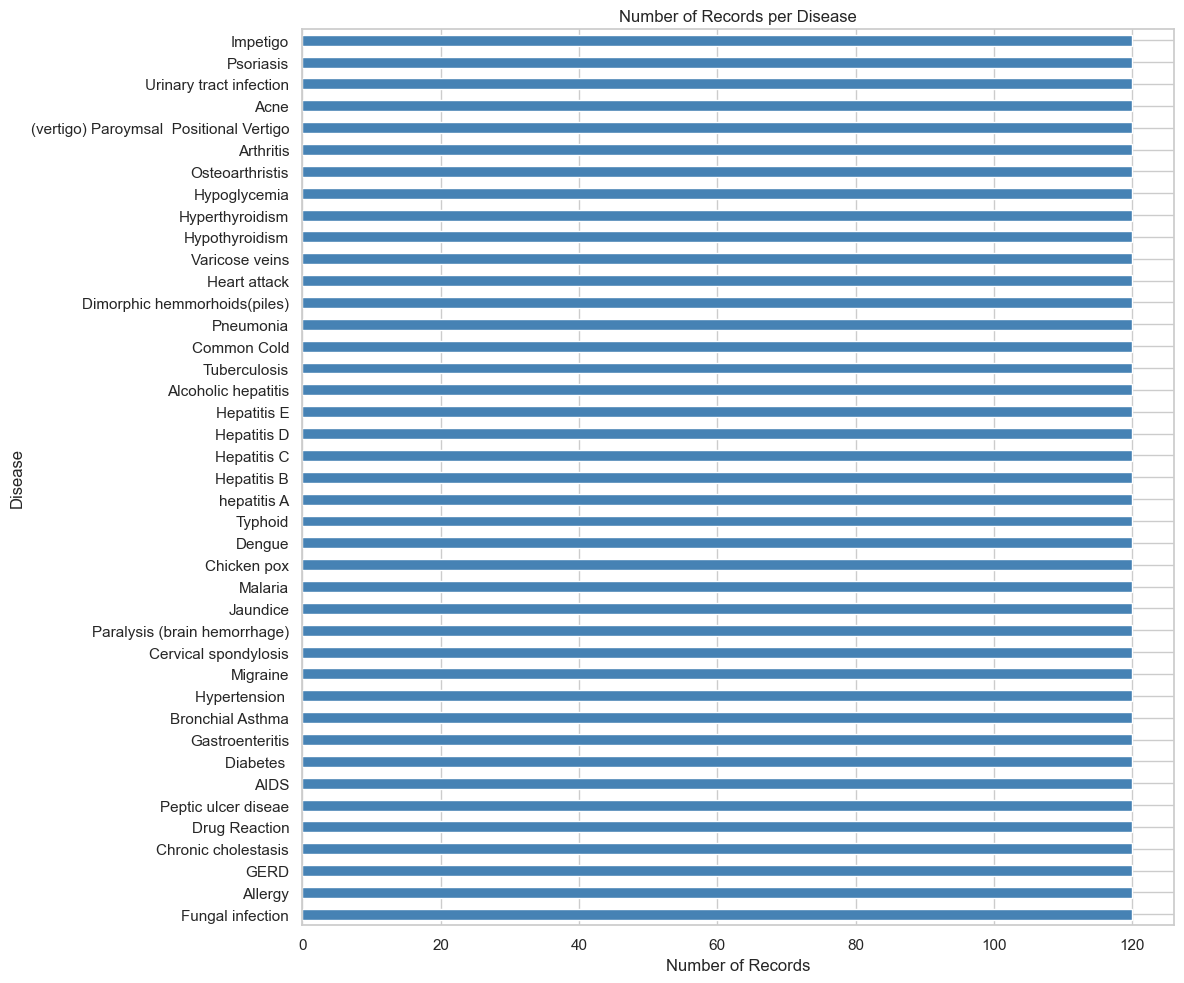

In [52]:
# Bar chart: number of records per disease
fig, ax = plt.subplots(figsize=(12, 10))
disease_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of Records")
ax.set_ylabel("Disease")
ax.set_title("Number of Records per Disease")
plt.tight_layout()
plt.show()

In [53]:
# Class balance assessment
ratio = disease_counts.max() / disease_counts.min()
print(f"Max/Min ratio: {ratio:.1f}x")
if ratio <= 2:
    print("Assessment: Dataset is relatively BALANCED — good for ML training.")
else:
    print("Assessment: Dataset is IMBALANCED — may need class weighting or resampling.")

Max/Min ratio: 1.0x
Assessment: Dataset is relatively BALANCED — good for ML training.


## 4. Symptom Analysis

In [54]:
# Count frequency of each symptom across all Symptom columns
symptom_freq = {}
for col in symptom_cols:
    counts = df_disease[col].dropna().str.strip().value_counts()
    for symptom, count in counts.items():
        if symptom:  # skip empty strings
            symptom_freq[symptom] = symptom_freq.get(symptom, 0) + count

# Convert to Series and sort
symptom_freq_series = pd.Series(symptom_freq).sort_values(ascending=False)
print(f"Top 20 most frequent symptoms:\n")
symptom_freq_series.head(20)

Top 20 most frequent symptoms:



fatigue              1932
vomiting             1914
high_fever           1362
loss_of_appetite     1152
nausea               1146
headache             1134
abdominal_pain       1032
yellowish_skin        912
yellowing_of_eyes     816
chills                798
skin_rash             786
malaise               702
chest_pain            696
joint_pain            684
itching               678
sweating              678
dark_urine            570
cough                 564
diarrhoea             564
muscle_pain           474
dtype: int64

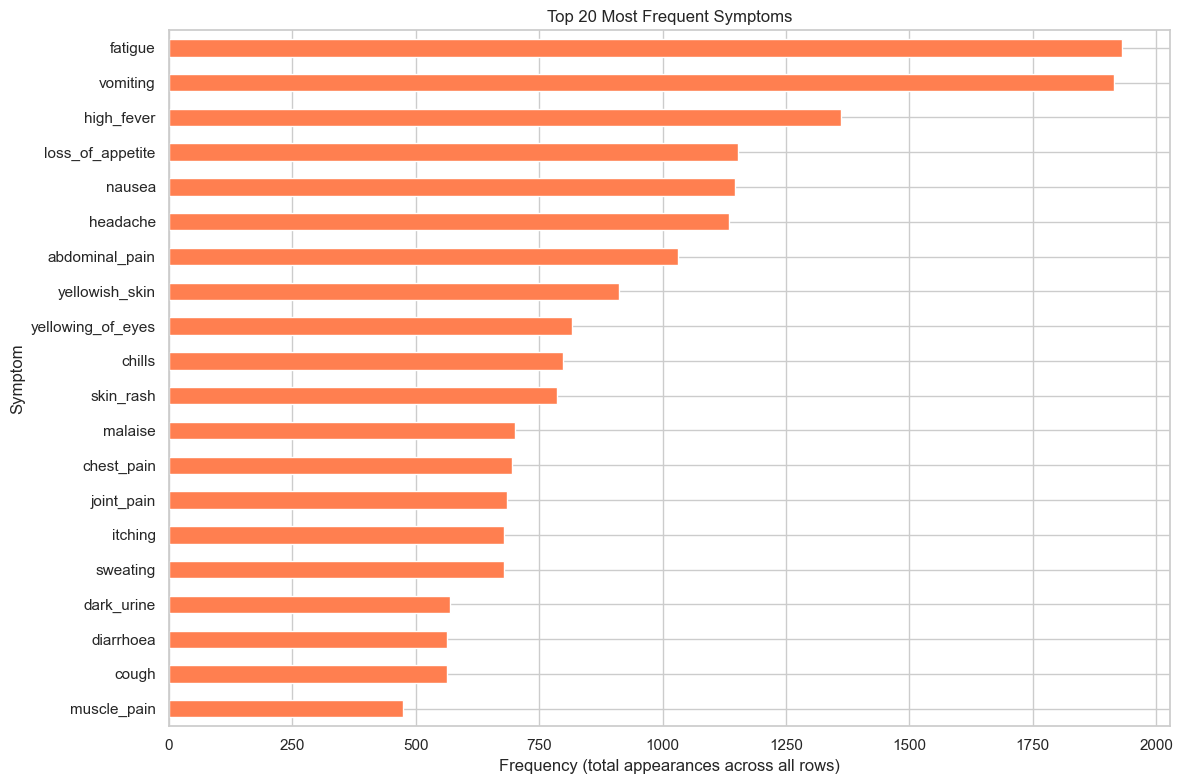

In [55]:
# Bar chart: top 20 most common symptoms
fig, ax = plt.subplots(figsize=(12, 8))
symptom_freq_series.head(20).sort_values().plot(kind="barh", ax=ax, color="coral")
ax.set_xlabel("Frequency (total appearances across all rows)")
ax.set_ylabel("Symptom")
ax.set_title("Top 20 Most Frequent Symptoms")
plt.tight_layout()
plt.show()

In [56]:
# How many symptoms does each disease typically have?
# Count non-null symptom columns per row
df_disease["symptom_count"] = df_disease[symptom_cols].notna().sum(axis=1)

symptom_stats = df_disease.groupby("Disease")["symptom_count"].agg(["mean", "min", "max"])
symptom_stats.columns = ["Avg Symptoms", "Min Symptoms", "Max Symptoms"]
symptom_stats = symptom_stats.sort_values("Avg Symptoms", ascending=False)

print(f"Symptoms per disease (across all diseases):")
print(f"  Average: {df_disease['symptom_count'].mean():.1f}")
print(f"  Min:     {df_disease['symptom_count'].min()}")
print(f"  Max:     {df_disease['symptom_count'].max()}")
print()
symptom_stats

Symptoms per disease (across all diseases):
  Average: 7.4
  Min:     3
  Max:     17



,Avg Symptoms,Min Symptoms,Max Symptoms
Disease,,,
Common Cold,16.60,16,17
Tuberculosis,15.60,15,16
Dengue,13.55,13,14
Hepatitis E,12.60,12,13
Hypothyroidism,12.60,12,13
Hypoglycemia,11.60,11,12
Hepatitis B,11.60,11,12
Hyperthyroidism,10.60,10,11
Pneumonia,10.60,10,11


## 5. Severity Weights

In [57]:
# Display full severity table
print(f"Total symptoms with severity weights: {len(df_severity)}")
df_severity.sort_values("weight", ascending=False)

Total symptoms with severity weights: 133


,Symptom,weight
113,coma,7
46,swelling_of_stomach,7
56,chest_pain,7
57,weakness_in_limbs,7
25,high_fever,7
...,...,...
121,painful_walking,2
126,silver_like_dusting,2
127,small_dents_in_nails,2
130,red_sore_around_nose,2


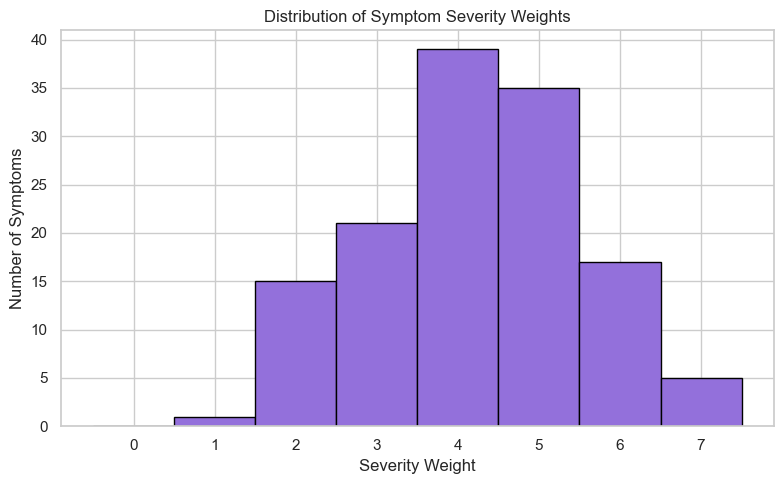

In [58]:
# Distribution of severity weights
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_severity["weight"], bins=range(0, df_severity["weight"].max() + 2),
        edgecolor="black", color="mediumpurple", align="left")
ax.set_xlabel("Severity Weight")
ax.set_ylabel("Number of Symptoms")
ax.set_title("Distribution of Symptom Severity Weights")
ax.set_xticks(range(0, df_severity["weight"].max() + 1))
plt.tight_layout()
plt.show()

In [59]:
# Highest severity symptoms
max_weight = df_severity["weight"].max()
print(f"Highest severity weight: {max_weight}")
print("Symptoms with highest severity:")
print(df_severity[df_severity["weight"] == max_weight]["Symptom"].tolist())

# Lowest severity symptoms
min_weight = df_severity["weight"].min()
print(f"\nLowest severity weight: {min_weight}")
print("Symptoms with lowest severity:")
print(df_severity[df_severity["weight"] == min_weight]["Symptom"].tolist())

Highest severity weight: 7
Symptoms with highest severity:
['high_fever', 'swelling_of_stomach', 'chest_pain', 'weakness_in_limbs', 'coma']

Lowest severity weight: 1
Symptoms with lowest severity:
['itching']


## 6. Key Findings Summary

| Metric | Value |
|--------|-------|
| Total rows | *(run cells above to populate)* |
| Total diseases | ~41 |
| Total unique symptoms | *(run cells above)* |
| Symptom columns | 17 (Symptom_1 to Symptom_17) |
| Missing values | Expected in later symptom columns (not all diseases have 17 symptoms) |
| Class balance | Check max/min ratio above |

### Data Quality Notes
- Some symptom values have **leading spaces** — strip whitespace during preprocessing
- Symptoms use **underscores** instead of spaces (e.g., `skin_rash`) — normalize during feature engineering
- Missing symptom columns are **structurally expected**, not data quality issues

### Next Step
Create `urgency_mapping.csv` to map diseases to urgency levels (low / medium / high / critical) for integration with the CTAS rule-based safety layer.